In [1]:
# import libraries
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn import metrics
from scipy.spatial.distance import cdist
from sklearn import preprocessing as prep
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew
from scipy.stats import zscore

# Set plot styles for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [2]:
# Define the path to the CSV dataset
file_path = 'Data/IBM_HR_EMPLOYEE.csv'

# Function to load a CSV file into a DataFrame
def load_csv_to_dataframe(path):
    """
    Loads a CSV file into a pandas DataFrame.
    
    Parameters:
    - path (str): The file path to the CSV file
    
    Returns:
    - DataFrame: Loaded dataset
    """
    df_raw = pd.read_csv(path)
    return df_raw

# Load the dataset
print("Loading IBM HR Employee Attrition dataset...")
df_raw = load_csv_to_dataframe(file_path)

# Confirm the dataset was loaded
print("Dataset loaded with shape:", df_raw.shape)

# Create a working copy for processing
df = df_raw.copy()

# Set display option to show all columns
pd.set_option('display.max_columns', None)

Loading IBM HR Employee Attrition dataset...
Dataset loaded with shape: (1470, 35)


In [3]:
# Set display option for wide datasets
pd.set_option('display.max_columns', None)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
missing = df.isnull().sum()
display(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

'No missing values found.'

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


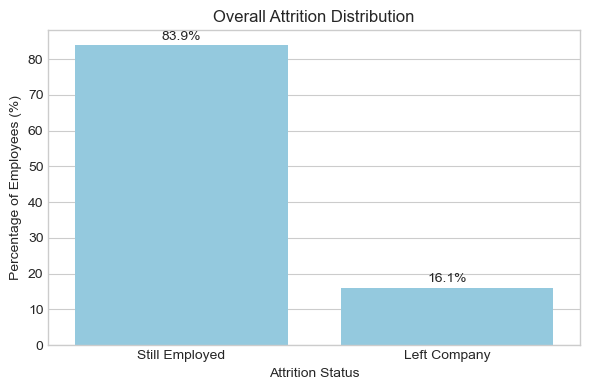

In [8]:
# Prepare data with readable labels
attrition_labeled = df['Attrition'].map({'Yes': 'Left Company', 'No': 'Still Employed'})

# Calculate percentage distribution
attrition_pct = (
    attrition_labeled.value_counts(normalize=True)
    .rename_axis('Attrition Status')
    .reset_index(name='Percentage')
)
attrition_pct['Percentage'] *= 100

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=attrition_pct, x='Attrition Status', y='Percentage', color='skyblue')

# Add percentage labels
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f%%', padding=2)

plt.title("Overall Attrition Distribution")
plt.xlabel("Attrition Status")
plt.ylabel("Percentage of Employees (%)")
plt.tight_layout()
plt.show()

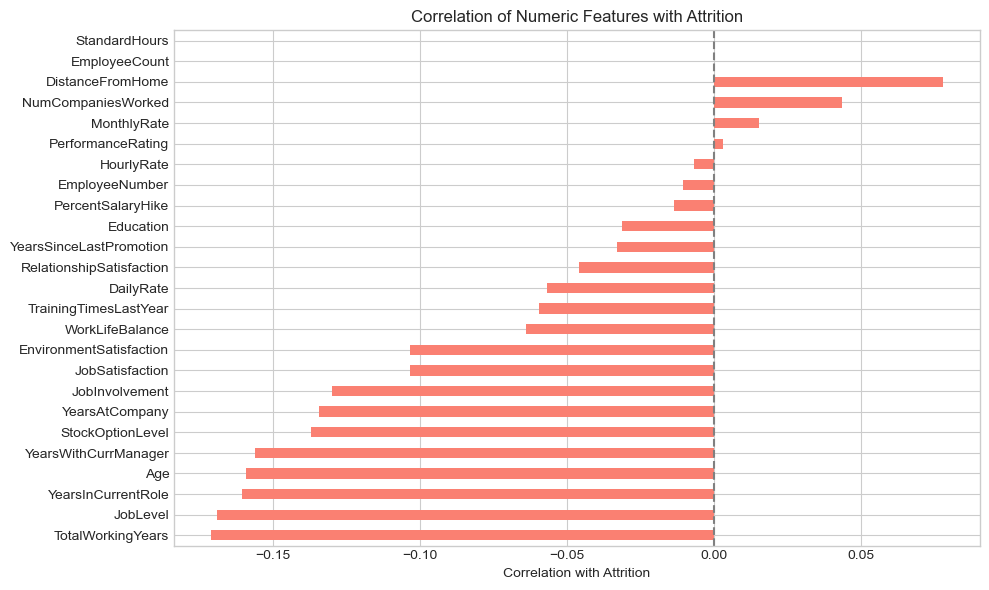

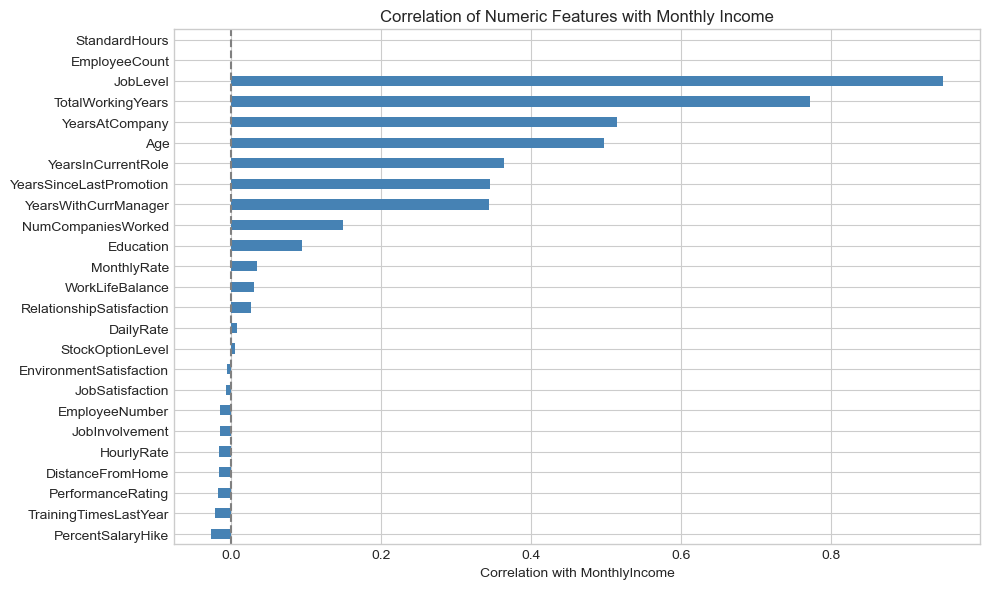

In [9]:
# Copy and encode Attrition
df_corr_target = df.copy()
if df_corr_target['Attrition'].dtype == 'object':
    df_corr_target['Attrition'] = df_corr_target['Attrition'].map({'Yes': 1, 'No': 0})

# Keep only numeric columns
numeric_df = df_corr_target.select_dtypes(include=['int64', 'float64'])

# Correlation with Attrition and MonthlyIncome
target_corr = numeric_df.corr()[['Attrition', 'MonthlyIncome']].drop(['Attrition', 'MonthlyIncome'])

# Plot: Correlation with Attrition
plt.figure(figsize=(10, 6))
target_corr['Attrition'].sort_values().plot(kind='barh', color='salmon')
plt.title("Correlation of Numeric Features with Attrition")
plt.xlabel("Correlation with Attrition")
plt.axvline(x=0, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

# Plot: Correlation with MonthlyIncome
plt.figure(figsize=(10, 6))
target_corr['MonthlyIncome'].sort_values().plot(kind='barh', color='steelblue')
plt.title("Correlation of Numeric Features with Monthly Income")
plt.xlabel("Correlation with MonthlyIncome")
plt.axvline(x=0, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

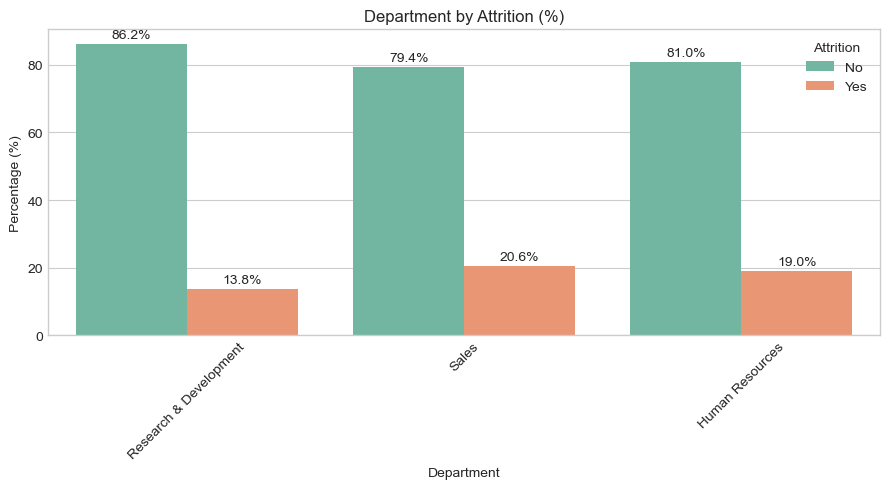

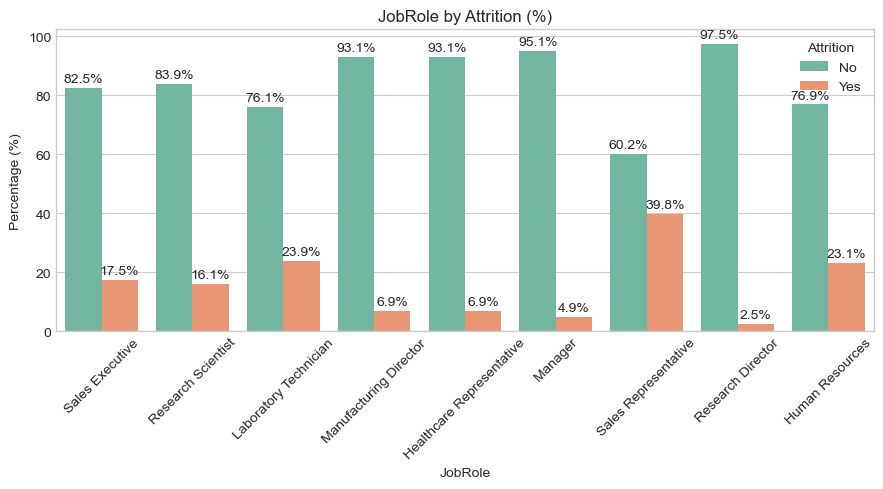

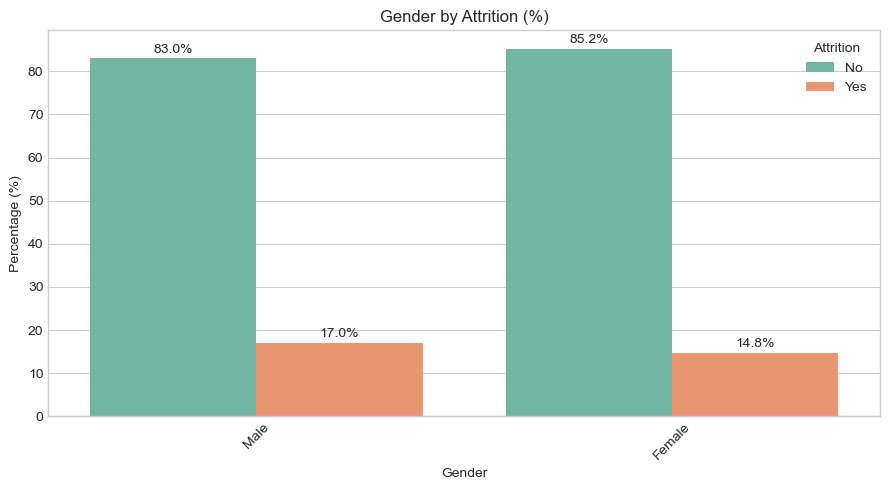

In [10]:
categorical_cols = ['Department', 'JobRole', 'Gender']

for col in categorical_cols:
    # Calculate % attrition within each category
    percent_df = (
        df.groupby(col)['Attrition']
        .value_counts(normalize=True)
        .rename('percentage')
        .mul(100)
        .reset_index()
    )

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(
        data=percent_df,
        x=col,
        y='percentage',
        hue='Attrition',
        order=df[col].value_counts().index,
        palette='Set2'
    )

    # Add percentage labels on each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2)

    plt.title(f"{col} by Attrition (%)")
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [11]:
# Attrition rate by department
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack().fillna(0) * 100
display(dept_attrition)

# Attrition rate by job role
role_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack().fillna(0) * 100
display(role_attrition)

# Attrition rate by gender
gender_attrition = df.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack().fillna(0) * 100
display(gender_attrition)

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


Average Monthly Income by Job Role:


,Job Role,Average Monthly Income
0,Manager,17181.68
1,Research Director,16033.55
2,Healthcare Representative,7528.76
3,Manufacturing Director,7295.14
4,Sales Executive,6924.28
5,Human Resources,4235.75
6,Research Scientist,3239.97
7,Laboratory Technician,3237.17
8,Sales Representative,2626.00


Average Monthly Income by Gender:


,Gender,Average Monthly Income
0,Female,6686.57
1,Male,6380.51


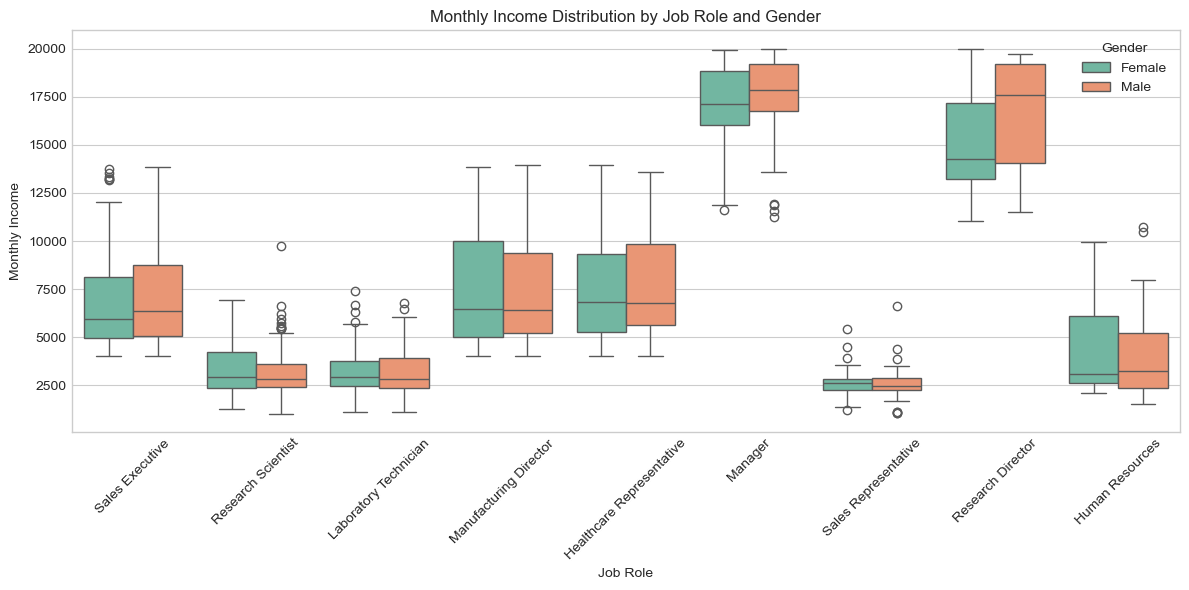

In [12]:
# Average Monthly Income by Job Role
job_income = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False).round(2)
job_income_df = job_income.to_frame().reset_index()
job_income_df.columns = ['Job Role', 'Average Monthly Income']

# Display neatly
print("Average Monthly Income by Job Role:")
display(job_income_df)

# Average Monthly Income by Gender
gender_income = df.groupby('Gender')['MonthlyIncome'].mean().round(2)
gender_income_df = gender_income.to_frame().reset_index()
gender_income_df.columns = ['Gender', 'Average Monthly Income']

print("Average Monthly Income by Gender:")
display(gender_income_df)

# Boxplot: Monthly Income by Job Role and Gender
plt.figure(figsize=(12, 6))
sns.boxplot(x='JobRole', y='MonthlyIncome', hue='Gender', data=df, palette='Set2')
plt.title("Monthly Income Distribution by Job Role and Gender")
plt.xticks(rotation=45)
plt.ylabel("Monthly Income")
plt.xlabel("Job Role")
plt.tight_layout()
plt.show()

Average Monthly Income by Job Role:


,Job Role,Average Monthly Income
0,Manager,17181.68
1,Research Director,16033.55
2,Healthcare Representative,7528.76
3,Manufacturing Director,7295.14
4,Sales Executive,6924.28
5,Human Resources,4235.75
6,Research Scientist,3239.97
7,Laboratory Technician,3237.17
8,Sales Representative,2626.00


Average Monthly Income by Gender:


,Gender,Average Monthly Income
0,Female,6686.57
1,Male,6380.51


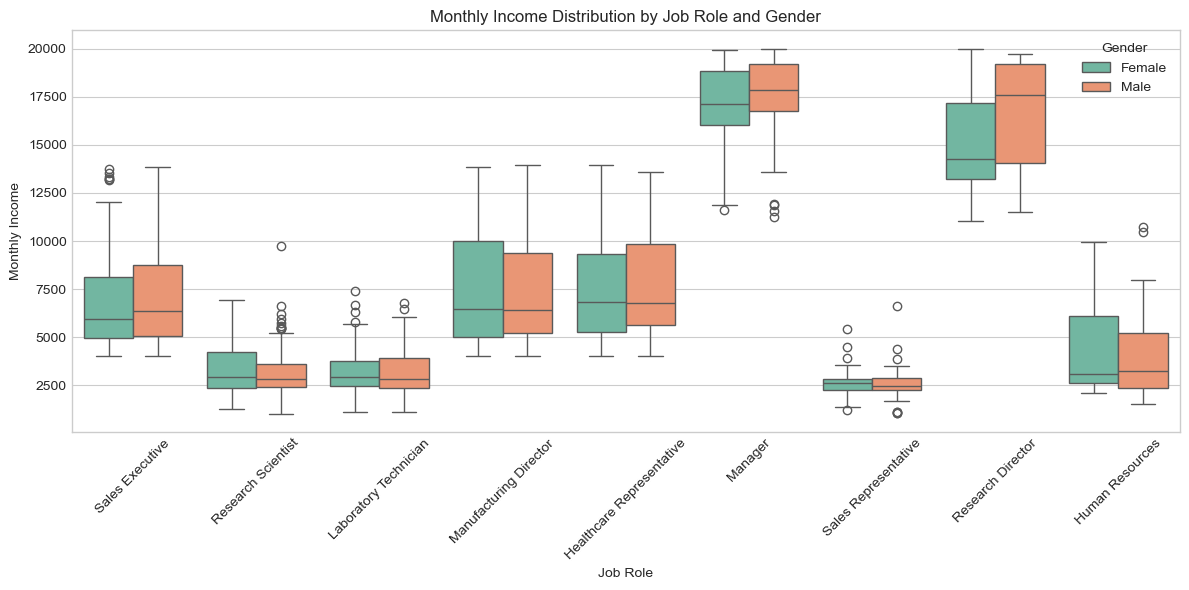

In [13]:
# Table: Average Monthly Income by Job Role
job_income = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False).round(2)
job_income_df = job_income.to_frame().reset_index()
job_income_df.columns = ['Job Role', 'Average Monthly Income']

print("Average Monthly Income by Job Role:")
display(job_income_df)

# Table: Average Monthly Income by Gender
gender_income = df.groupby('Gender')['MonthlyIncome'].mean().round(2)
gender_income_df = gender_income.to_frame().reset_index()
gender_income_df.columns = ['Gender', 'Average Monthly Income']

print("Average Monthly Income by Gender:")
display(gender_income_df)

# Boxplot: Monthly Income Distribution by Job Role and Gender
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='JobRole', y='MonthlyIncome', hue='Gender', palette='Set2')
plt.title("Monthly Income Distribution by Job Role and Gender")
plt.xlabel("Job Role")
plt.ylabel("Monthly Income")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder


# Create a working copy
df_encoded = df.copy()

# Binary categorical columns
binary_cols = ['Attrition', 'OverTime', 'Gender', 'Over18']

# Apply label encoding
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [15]:
# Multi-class categorical columns
multi_class_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

# Only keep existing columns to avoid KeyError
existing_cols = [col for col in multi_class_cols if col in df_encoded.columns]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=existing_cols, drop_first=True)

# Save df_encoded (post-encoding, pre-scaling)
df_encoded.to_csv('Data/df_encoded.csv', index=False)
print("df_encoded saved successfully.")

df_encoded saved successfully.


In [16]:
# Copy to df_clean
df_clean = df_encoded.copy()

# Select features to scale (exclude target)
features_to_scale = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
features_to_scale.remove('MonthlyIncome')  # Target variable for regression

# Apply StandardScaler
scaler = StandardScaler()
df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

# Confirm scaling
df_clean.head()

# Save the final cleaned dataset
df_clean.to_csv('Data/df_clean.csv', index=False)
print("df_clean saved successfully.")

df_clean saved successfully.


## Task 2: Supervised Machine Learning – Linear Regression

In [17]:
from sklearn.model_selection import train_test_split

# Define target and features
X = df_clean.drop(columns=['MonthlyIncome'])
y = df_clean['MonthlyIncome']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1176, 48)
Test set shape: (294, 48)


In [18]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Predict on test set
y_pred = reg_model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 891.76
Root Mean Squared Error (RMSE): 1165.71
R² Score: 0.9378


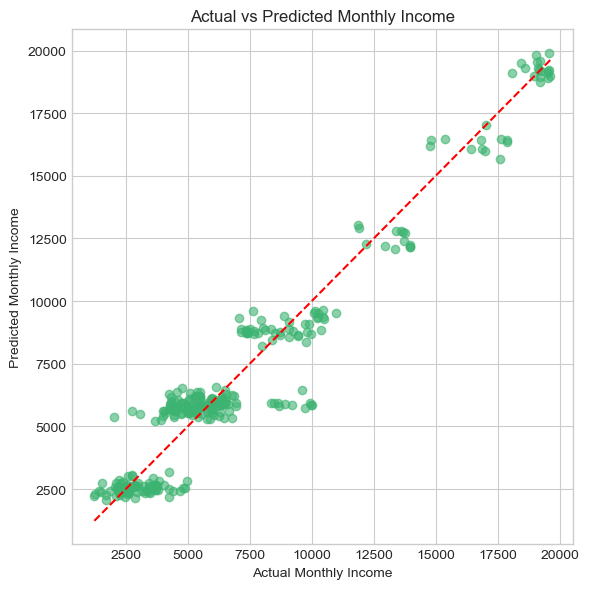

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Monthly Income")
plt.ylabel("Predicted Monthly Income")
plt.title("Actual vs Predicted Monthly Income")
plt.tight_layout()
plt.show()

In [21]:
import os
# Ensure directory exists
os.makedirs('models', exist_ok=True)

# Save the linear regression model
joblib.dump(reg_model, 'models/linear_regression_model.pkl')

# Save the scaler used for standardizing the features
joblib.dump(scaler, 'models/feature_scaler.pkl')

# Optional: Save the clean dataset (without target)
df_clean.drop(columns=['MonthlyIncome']).to_csv('Data/clean_features.csv', index=False)

# Save the linear regression model
joblib.dump(reg_model, 'models/linear_regression_model_2.pkl')

# Save the scaler used for standardizing the features
joblib.dump(scaler, 'models/feature_scaler.pkl')

# Optional: Save the clean dataset (without target)
df_clean.drop(columns=['MonthlyIncome']).to_csv('Data/clean_features.csv', index=False)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Define feature columns
numeric_features = ['Age', 'DistanceFromHome', 'JobSatisfaction', 'PerformanceRating', 'YearsAtCompany']
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Combine into preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

# Create pipeline
reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit pipeline
reg_pipeline.fit(X_train[numeric_features], y_train)

# Save the entire pipeline (no need to save scaler separately)
joblib.dump(reg_pipeline, 'app/models/regression_pipeline.pkl')

['app/models/regression_pipeline.pkl']

In [23]:
# Create a DataFrame to view feature coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg_model.coef_
}).sort_values(by='Coefficient', ascending=False)

# Display top and bottom contributing features
print("Top 10 Features Increasing Salary:")
display(coefficients.head(10))

print("Top 10 Features Decreasing Salary:")
display(coefficients.tail(10))

Top 10 Features Increasing Salary:


,Feature,Coefficient
40,JobRole_Manager,4382.046775
42,JobRole_Research Director,3994.342365
11,JobLevel,3104.366349
31,Department_Research & Development,427.731038
44,JobRole_Sales Executive,378.584827
22,TotalWorkingYears,333.226693
38,JobRole_Human Resources,167.902081
30,BusinessTravel_Travel_Rarely,165.816345
29,BusinessTravel_Travel_Frequently,161.446818
32,Department_Sales,89.115160


Top 10 Features Decreasing Salary:


,Feature,Coefficient
18,PerformanceRating,-67.076410
34,EducationField_Marketing,-78.370446
35,EducationField_Medical,-86.311442
37,EducationField_Technical Degree,-88.244302
28,YearsWithCurrManager,-107.662797
33,EducationField_Life Sciences,-132.369937
45,JobRole_Sales Representative,-251.778437
36,EducationField_Other,-261.900309
43,JobRole_Research Scientist,-374.933363
39,JobRole_Laboratory Technician,-472.513920


In [24]:
X = df_clean.drop(columns=['MonthlyIncome'])  # drop only target
y = df_clean['MonthlyIncome']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.metrics import r2_score

y_pred_test = reg_model.predict(X_test)
print("R²-score on test data:", round(r2_score(y_test, y_pred_test), 4))

R²-score on test data: 0.9378


In [26]:
# Use the mean of training data as a realistic new employee profile
new_employee_input = pd.DataFrame([X_train.mean()], columns=X_train.columns)

# Predict using trained model
predicted_income = reg_model.predict(new_employee_input)

print("Predicted monthly income for a new employee:", round(predicted_income[0], 2))

Predicted monthly income for a new employee: 6382.52


In [27]:
features_to_scale = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
features_to_scale.remove('MonthlyIncome')

def predict_income_for_employee(raw_features: dict, reg_model, scaler, features_to_scale, reference_columns):
    import pandas as pd
    import numpy as np

    # Create initial DataFrame
    df = pd.DataFrame([raw_features])

    # Add any missing columns (fill with 0)
    for col in reference_columns:
        if col not in df.columns:
            df[col] = 0

    # Ensure correct column order
    df = df[reference_columns]

    # Scale only the original numeric columns
    df_scaled = df.copy()
    df_scaled[features_to_scale] = scaler.transform(df_scaled[features_to_scale])

    # Predict
    prediction = reg_model.predict(df_scaled)
    return round(prediction[0], 2)

In [28]:
# Define raw employee profile (with all categorical + numeric inputs)
employee_input = {
    'Age': 35,
    'TotalWorkingYears': 10,
    'JobLevel': 2,
    'YearsAtCompany': 4,
    'Education': 3,
    'DistanceFromHome': 8,
    'NumCompaniesWorked': 2,
    'PercentSalaryHike': 12,
    'YearsInCurrentRole': 2,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 3,
    'OverTime': 1,
    'Gender': 1,
    'Over18': 1,
    'PerformanceRating': 3,
    'JobInvolvement': 3,
    'JobSatisfaction': 3,
    'EnvironmentSatisfaction': 3,
    'WorkLifeBalance': 3,
    'RelationshipSatisfaction': 3,
    'TrainingTimesLastYear': 3,
    'StockOptionLevel': 1,
    'DailyRate': 1000,
    'HourlyRate': 70,
    'MonthlyRate': 20000,
    'EmployeeCount': 1,
    'EmployeeNumber': 9999,
    'Attrition': 0,
    'StandardHours': 40,
    'BusinessTravel_Travel_Frequently': 0,
    'BusinessTravel_Travel_Rarely': 1,
    'Department_Research & Development': 0,
    'Department_Sales': 1,
    'EducationField_Life Sciences': 1,
    'EducationField_Marketing': 0,
    'EducationField_Medical': 0,
    'EducationField_Other': 0,
    'EducationField_Technical Degree': 0,
    'JobRole_Human Resources': 0,
    'JobRole_Laboratory Technician': 0,
    'JobRole_Manager': 0,
    'JobRole_Manufacturing Director': 0,
    'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0,
    'JobRole_Sales Executive': 1,
    'JobRole_Sales Representative': 0,
    'MaritalStatus_Married': 0,
    'MaritalStatus_Single': 1
}

# Call the function
predicted_income = predict_income_for_employee(
    raw_features=employee_input,
    reg_model=reg_model,
    scaler=scaler,
    features_to_scale=features_to_scale,
    reference_columns=X_train.columns.tolist()
)

print("Predicted Monthly Income:", predicted_income)

Predicted Monthly Income: 6342.55


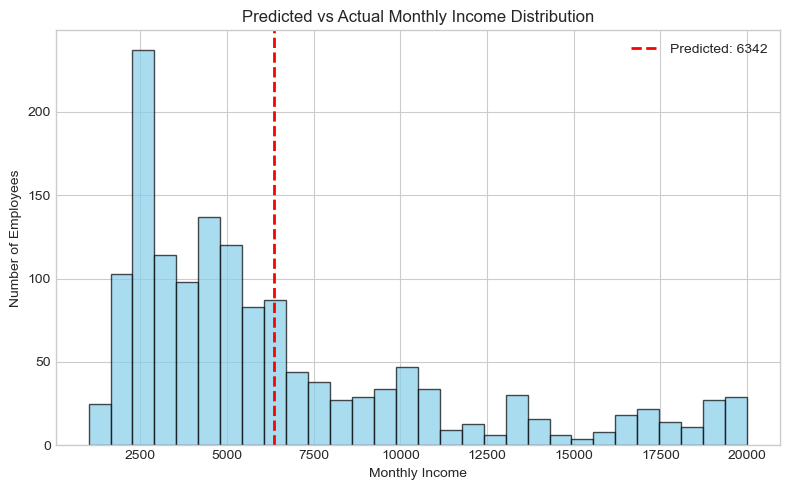

In [29]:
# Example: 
income_distribution = df['MonthlyIncome']

# Plot histogram of real salaries
plt.figure(figsize=(8, 5))
plt.hist(income_distribution, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(predicted_income, color='red', linestyle='--', linewidth=2, label=f"Predicted: {int(predicted_income)}")

plt.title("Predicted vs Actual Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

In [31]:
print(df_encoded['Attrition'].unique())

[1 0]


In [32]:
# Use encoded dataset (no scaling needed for logistic regression)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,3,2,4,5993,19479,8,0,1,11,3,1,80,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,1,2,3,1,61,2,2,2,5130,24907,1,0,0,23,4,4,80,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,1,4,4,1,92,2,1,3,2090,2396,6,0,1,15,3,2,80,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,1,5,4,0,56,3,1,3,2909,23159,1,0,1,11,3,3,80,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,7,1,1,40,3,1,2,3468,16632,9,0,0,12,3,4,80,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False


In [33]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

C:\Users\Malou\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
clf = LogisticRegression(solver='liblinear', max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [35]:
import joblib

# After training the pipeline
reg_pipeline.fit(X_train, y_train)

# Save it
joblib.dump(reg_pipeline, "app/models/regression_pipeline.pkl")

['app/models/regression_pipeline.pkl']

Accuracy: 0.8707482993197279
Precision: 0.8
Recall: 0.2553191489361702
F1 Score: 0.3870967741935484


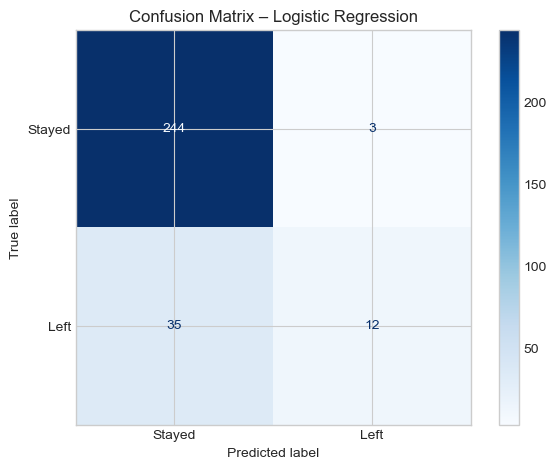

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Scores
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Left"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.tight_layout()
plt.show()

In [37]:
# Restore df_clean from df_encoded
df_clean = df_encoded.copy()

# Just to be sure, cast Attrition to int (should already be 0/1)
df_clean['Attrition'] = df_clean['Attrition'].astype(int)

# Confirm it's fixed
print("Unique Attrition values:", df_clean['Attrition'].unique())
print("df_clean shape:", df_clean.shape)

Unique Attrition values: [1 0]
df_clean shape: (1470, 49)


In [38]:
# View current unique values before changing anything
print("Before fix:", df_clean['Attrition'].unique())

Before fix: [1 0]


In [39]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [40]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1176, 48)
Test size: (294, 48)


Accuracy: 0.8809523809523809

Classification Report:

              precision    recall  f1-score   support

      Stayed       0.89      0.98      0.93       247
        Left       0.77      0.36      0.49        47

    accuracy                           0.88       294
   macro avg       0.83      0.67      0.71       294
weighted avg       0.87      0.88      0.86       294



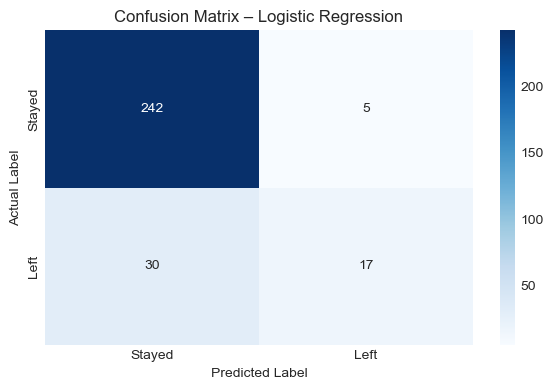

In [41]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Train the model
clf = LogisticRegression(max_iter=1000, solver='liblinear')
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))

# Confusion Matrix (with labels)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Stayed", "Left"],
            yticklabels=["Stayed", "Left"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix – Logistic Regression")
plt.tight_layout()
plt.show()

In [42]:
# Get predicted probabilities of class 1 (attrition = Yes)
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

# Copy the X_test data into a new DataFrame for analysis
df_pred = X_test.copy()
df_pred['Actual Attrition'] = y_test.values
df_pred['Predicted Attrition'] = y_pred
df_pred['Attrition Probability'] = y_proba

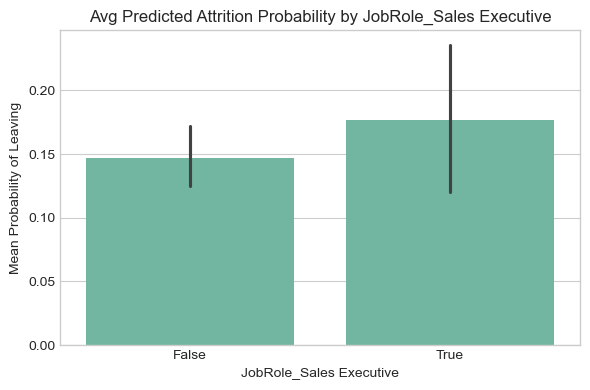

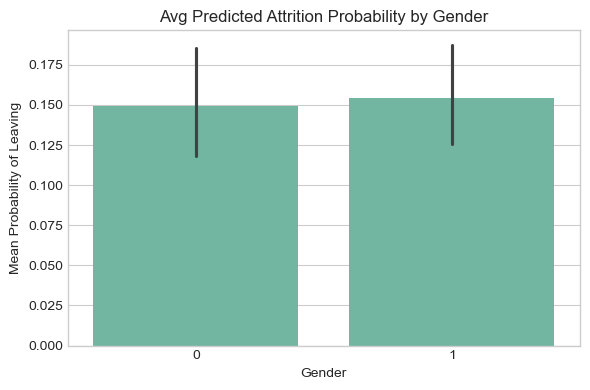

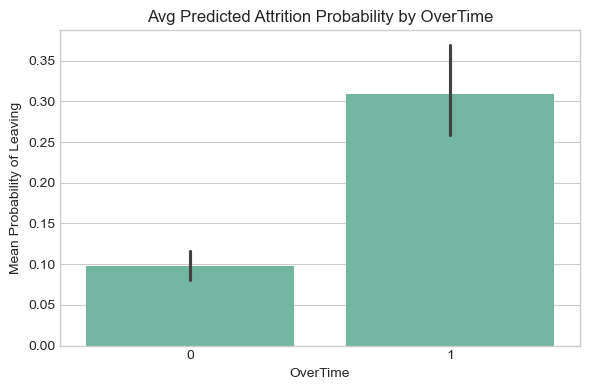

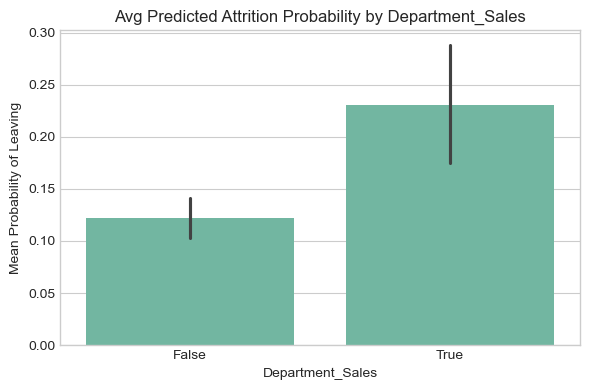

In [43]:
# Choose categorical features to analyze
categories = ['JobRole_Sales Executive', 'Gender', 'OverTime', 'Department_Sales']

for col in categories:
    if col in df_pred.columns:
        # Plot average predicted attrition probability by category
        plt.figure(figsize=(6, 4))
        sns.barplot(x=df_pred[col], y=df_pred['Attrition Probability'])
        plt.title(f"Avg Predicted Attrition Probability by {col}")
        plt.ylabel("Mean Probability of Leaving")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

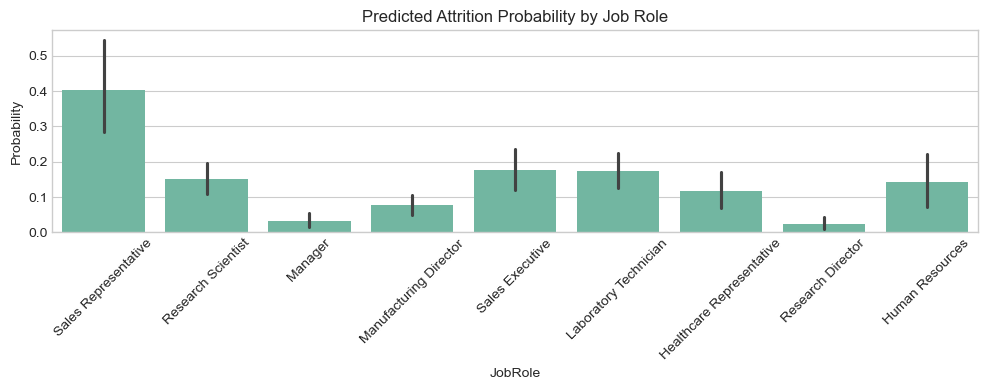

In [44]:
df_test_raw = df.iloc[X_test.index].copy()  # Use unencoded data for JobRole
df_test_raw['Predicted'] = y_pred
df_test_raw['Probability'] = y_proba

# Example: average attrition probability by JobRole
plt.figure(figsize=(10, 4))
sns.barplot(data=df_test_raw, x='JobRole', y='Probability')
plt.title("Predicted Attrition Probability by Job Role")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

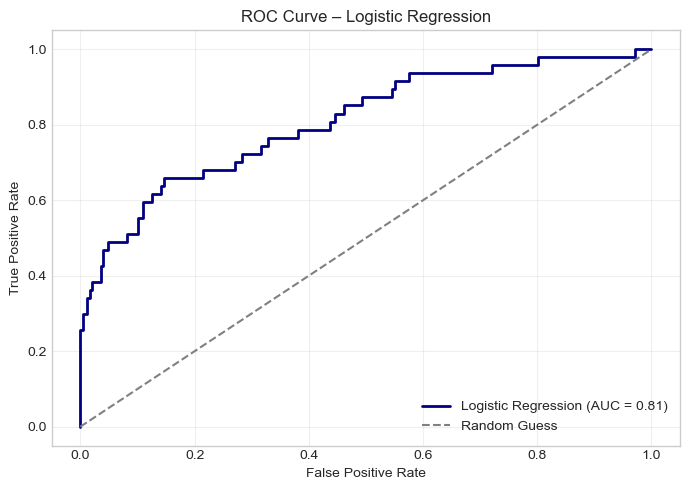

In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities for the positive class (Attrition = 1)
y_proba_lr = clf.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})", color='navy', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Random Forest
Accuracy : 0.826530612244898
Recall   : 0.0425531914893617
F1 Score : 0.07272727272727272


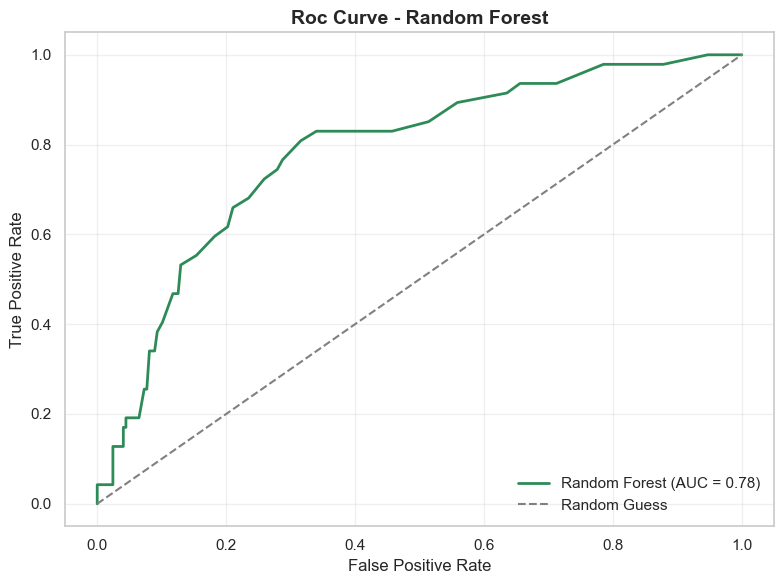

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Metrics
print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

# ROC curve and AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plotting
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curves
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})", color='seagreen', linewidth=2)

# Diagonal reference
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label="Random Guess")

# Aesthetics
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Roc Curve - Random Forest", fontsize=14, weight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Logistic Regression (Balanced)
Accuracy : 0.7482993197278912
Recall   : 0.6595744680851063
F1 Score : 0.45588235294117646


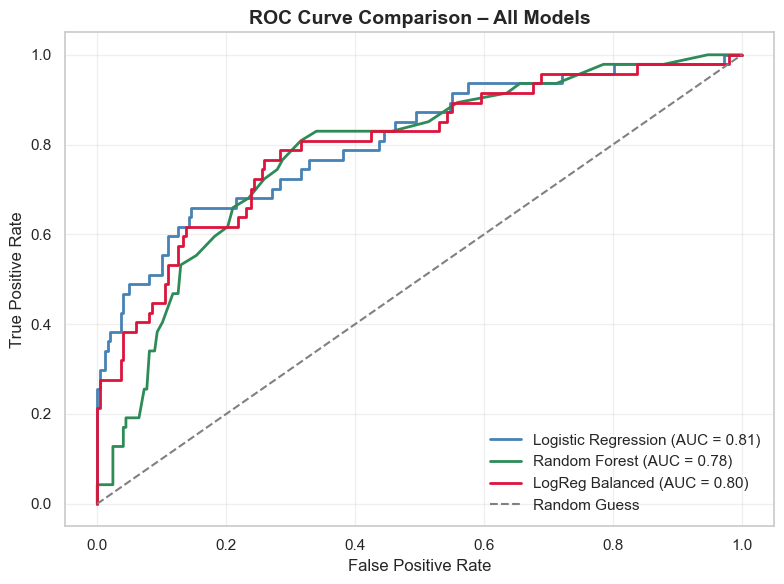

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# === Balanced Logistic Regression ===
clf_balanced = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')
clf_balanced.fit(X_train, y_train)

y_pred_bal = clf_balanced.predict(X_test)
y_proba_bal = clf_balanced.predict_proba(X_test)[:, 1]

print("Logistic Regression (Balanced)")
print("Accuracy :", accuracy_score(y_test, y_pred_bal))
print("Recall   :", recall_score(y_test, y_pred_bal))
print("F1 Score :", f1_score(y_test, y_pred_bal))

# === ROC curves for all models ===
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_proba_bal)
roc_auc_bal = auc(fpr_bal, tpr_bal)

# Plot settings
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# Plot ROC curves
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})", color='steelblue', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})", color='seagreen', linewidth=2)
plt.plot(fpr_bal, tpr_bal, label=f"LogReg Balanced (AUC = {roc_auc_bal:.2f})", color='crimson', linewidth=2)

# Random guess line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label="Random Guess")

# Labels and legend
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison – All Models", fontsize=14, weight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'JobSatisfaction', 'PerformanceRating', 'YearsAtCompany']

cluster_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42))  # or the optimal k
])

cluster_pipeline.fit(df[cluster_features])  # IMPORTANT: match these features

import joblib
joblib.dump(cluster_pipeline, "app/models/cluster_pipeline.pkl")

['app/models/cluster_pipeline.pkl']

In [49]:
import pandas as pd
import joblib

# Sample input (must match the training features used in pipeline)
input_df = pd.DataFrame([{
    "Age": 35,
    "DistanceFromHome": 10,
    "MonthlyIncome": 6000,
    "JobSatisfaction": 3,
    "PerformanceRating": 3,
    "YearsAtCompany": 5
}])

# Load pipeline
model = joblib.load("app/models/cluster_pipeline.pkl")  # adjust path as needed

# Predict cluster
cluster = model.predict(input_df)[0]
print("Predicted cluster:", cluster)

Predicted cluster: 1


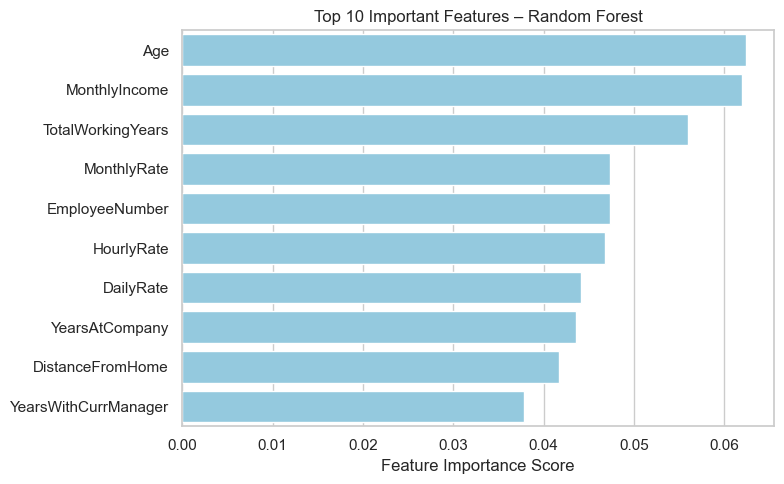

In [50]:
# Random Forest: feature importances
importances_rf = rf_clf.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

# Plot top 10
plt.figure(figsize=(8, 5))
sns.barplot(
    data=rf_importance_df.head(10),
    x='Importance',
    y='Feature',
    color='skyblue',  # one solid color
    errorbar=None
)
plt.title("Top 10 Important Features – Random Forest")
plt.xlabel("Feature Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

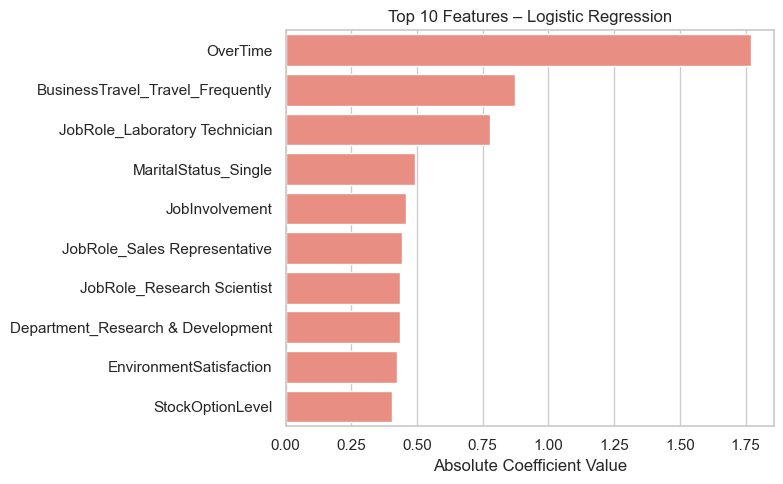

In [51]:
# Logistic Regression: absolute coefficient values
coef_lr = pd.Series(clf.coef_[0], index=X_train.columns)
coef_abs_df = pd.DataFrame({
    'Feature': coef_lr.index,
    'Coefficient Magnitude': coef_lr.abs()
}).sort_values(by='Coefficient Magnitude', ascending=False)

# Plot top 10
plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_abs_df.head(10),
    x='Coefficient Magnitude',
    y='Feature',
    color='salmon',  # one solid color
    errorbar=None
)
plt.title("Top 10 Features – Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler

# Use df_clean and drop non-feature columns (like Attrition)
X_cluster = df_clean.drop(columns=['Attrition'])

# Scale the features (important for distance-based methods like K-Means)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    sil_scores.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.0841
k = 3, Silhouette Score = 0.0943
k = 4, Silhouette Score = 0.0718
k = 5, Silhouette Score = 0.0703
k = 6, Silhouette Score = 0.0815
k = 7, Silhouette Score = 0.1010
k = 8, Silhouette Score = 0.1094
k = 9, Silhouette Score = 0.0903
k = 10, Silhouette Score = 0.0798


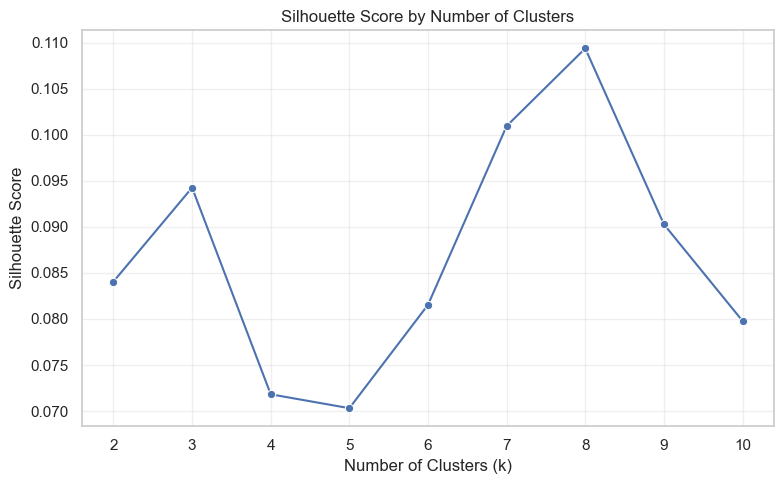

In [54]:
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(k_range), y=sil_scores, marker='o')
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# Choose the k with the highest silhouette score
optimal_k = k_range[sil_scores.index(max(sil_scores))]
print(f"Optimal number of clusters: {optimal_k}")

# Final KMeans model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to df_clean
df_clean['Cluster'] = cluster_labels

# Assign descriptive labels to each cluster
cluster_labels = {
    0: "Young Entry-Level",
    1: "Junior Admin",
    2: "Mid-Level Analysts",
    3: "Support Staff",
    4: "Senior Executives",
    5: "Skilled Technicians",
    6: "Experienced Managers",
    7: "Low Income, Low Tenure"
}

# Map to new column
df_clean['ClusterLabel'] = df_clean['Cluster'].map(cluster_labels)

Optimal number of clusters: 8


In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Define features used for clustering (same as X_cluster_scaled was based on)
cluster_features = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'JobSatisfaction', 'PerformanceRating', 'YearsAtCompany']

# Create pipeline with scaling + KMeans
cluster_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42))  # replace 3 with your optimal k
])

# Train the pipeline
cluster_pipeline.fit(df[cluster_features])

import joblib
joblib.dump(cluster_pipeline, "app/models/cluster_pipeline.pkl")

['app/models/cluster_pipeline.pkl']

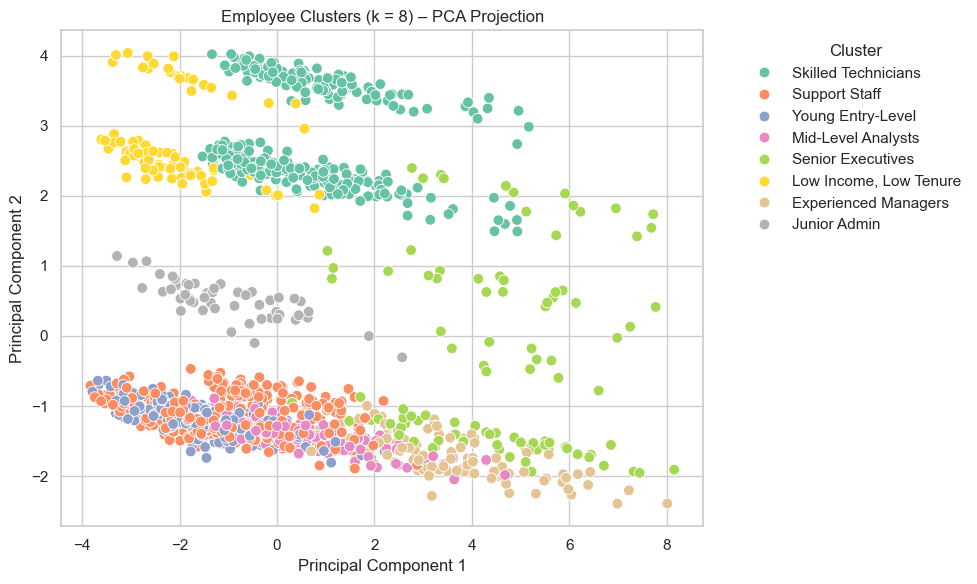

In [57]:
from sklearn.decomposition import PCA

# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# Add PCA components and cluster label to a DataFrame
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca['Cluster'] = df_clean['Cluster']
df_pca['ClusterLabel'] = df_clean['ClusterLabel']

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=df_clean['ClusterLabel'], palette='Set2', s=60)
plt.title("Employee Clusters (k = 8) – PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [58]:
# Cluster label mapping
label_map = {
    0: "Young Entry-Level",
    1: "Junior Admin",
    2: "Mid-Level Analysts",
    3: "Support Staff",
    4: "Senior Executives",
    5: "Skilled Technicians",
    6: "Experienced Managers",
    7: "Low Income, Low Tenure"
}

# Create the summary with labeled index
cluster_summary = df_clean.groupby('Cluster')[[
    'Age', 'TotalWorkingYears', 'JobLevel', 'MonthlyIncome', 'OverTime'
]].mean().round(1)

# Rename index to use descriptive labels
cluster_summary.index = cluster_summary.index.map(label_map)

display(cluster_summary)

,Age,TotalWorkingYears,JobLevel,MonthlyIncome,OverTime
Cluster,,,,,
Young Entry-Level,34.0,7.5,1.2,3213.3,0.2
Junior Admin,35.5,8.2,1.5,4235.8,0.2
Mid-Level Analysts,38.2,12.6,2.4,7252.7,0.3
Support Staff,35.4,8.8,1.5,4158.0,0.3
Senior Executives,46.9,24.7,4.3,17149.5,0.3
Skilled Technicians,36.8,11.0,2.3,6902.9,0.3
Experienced Managers,44.5,22.2,3.8,14686.8,0.3
"Low Income, Low Tenure",30.4,4.7,1.1,2626.0,0.3
